In [1]:
%load_ext autoreload
%autoreload 2

In [30]:
from __future__ import annotations

from pathlib import Path

import openpyxl
import pandas as pd
from loguru import logger
from tqdm import tqdm
import pandas as pd
from eu_survey_correlation.surveys import volume_b_parser
from loguru import logger
from tqdm import tqdm
import seaborn as sns

In [3]:
SURVEY_CSV = volume_b_parser.DATA_PATH / "surveys" / "michlou_survey_tri.csv"
parser_b = volume_b_parser.VolumeBParser()

In [4]:
df_surveys = pd.read_csv(SURVEY_CSV)
logger.info(f"Loaded {len(df_surveys)} questions from {SURVEY_CSV.name}")

2026-03-14 12:47:56.768 | INFO     | __main__:<module>:2 - Loaded 115 questions from michlou_survey_tri.csv


In [5]:
# Group by file to open each workbook only once

grouped = df_surveys.groupby("file_name")
all_results: list[dict] = []

for file_name, group in tqdm(grouped, desc="Processing files"):
    if file_name == "eb_93_volume_B.xlsx":
        print("here")
        break

Processing files:  65%|██████▍   | 20/31 [00:00<00:00, 31254.13it/s]

here


In [6]:
fpath = parser_b.volume_b_dir / file_name
wb = openpyxl.load_workbook(fpath, read_only=True, data_only=True)

In [7]:
for _, row in group.iterrows():
    sheet_id = str(row["sheet_id"]).strip()
    question_clean = str(row.get("question_clean", ""))
    print(sheet_id)
    print(question_clean)

T87
What should the European Union prioritize in its response to the Coronavirus outbreak?
T91
To what extent do you agree or disagree or totally disagree with the statement: The EU should put in place an economic plan to help all EU Member States recover from the Coronavirus outbreak? (N)
T92
To what extent do you agree or disagree or totally disagree that the EU should become less dependent on other countries for critical needs like medical and pharmaceutical goods due to the Coronavirus outbreak?
T95
To what extent do you agree or disagree or totally disagree with the statement: The EU should be given the means to better deal with future crises, such as the Coronavirus outbreak?


In [8]:
actual_sheet = None
if sheet_id in wb.sheetnames:
    actual_sheet = sheet_id
    print(actual_sheet)

T95


In [9]:
def detect_format(self, rows: list[tuple]) -> dict:
    """Auto-detect header layout by searching for 'Gender'/'Sexe' keyword."""
    cat_header_row = -1

    for ri in range(min(15, len(rows))):
        for ci, v in enumerate(rows[ri]):
            t = volume_b_parser._normalize(v)
            if not t:
                continue
            # Category headers are short (< 80 chars) — skip long question text
            if len(t) > 80:
                continue
            if ci >= 2 and ("gender" in t or "sexe" in t):
                cat_header_row = ri
                break
        if cat_header_row >= 0:
            break

In [ ]:
ws = wb[actual_sheet]
sheet_rows = list(ws.iter_rows(values_only=True))

results = parser_b.extract_sheet(sheet_rows, sheet_id, file_name, question_clean)

In [11]:
pd.DataFrame(results)

,sheet_id,file_name,question_clean,answer_label,is_summary,demographic_type,demographic_value,count,pct,total_base
0,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Totally agree,False,total,eu27,11095.0,42.0,26681.0
1,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Totally agree,False,gender,male,5248.0,41.0,12955.0
2,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Totally agree,False,gender,female,5847.0,43.0,13726.0
3,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Totally agree,False,occupation,self_employed,909.0,44.0,2087.0
4,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Totally agree,False,occupation,manager,1152.0,40.0,2900.0
...,...,...,...,...,...,...,...,...,...,...
128,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Total 'Disagree',True,class_belonging,working_class,537.0,9.0,6426.0
129,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Total 'Disagree',True,class_belonging,lower_middle,489.0,11.0,4427.0
130,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Total 'Disagree',True,class_belonging,middle,1473.0,12.0,13063.0
131,T95,eb_93_volume_B.xlsx,To what extent do you agree or disagree or tot...,Total 'Disagree',True,class_belonging,upper_middle,372.0,17.0,2236.0


In [ ]:
wb.close()

df_out = pd.DataFrame(all_results)
logger.info(
    f"Extracted {len(df_out)} rows "
    f"({df_out['sheet_id'].nunique()} questions, "
    f"{df_out['file_name'].nunique()} files)"
)
return df_out

In [2]:
import pandas as pd

In [ ]:
df = pd.read_csv(
    "/Users/ugo/Documents/MH2D_projets/dawta/eu_survey_correlation/data/surveys/volume_b_answer_distributions.csv"
)

In [ ]:
df.groupby(["file_name"]).agg(
    {"demographic_type": lambda x: (x == "class_belonging").sum()}
)

,demographic_type
file_name,
Fairness_perception_green_transition_2022_ebs_527_volume_B.xlsx,0
Identities_values_eb_508_volume_B.xlsx,1100
Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,165
Lien_vers_Eurobarometer_Standard_99_Spring_2023_volume_B.xlsx,110
Lien_vers_Eurobaromètre_Standard_STD102_Autumn_2024_volume_B.xlsx,310
Lien_vers_La_zone_euro_FL533_volume_B.xlsx,0
Lien_vers_SP546_volume_B.xlsx,155
Lien_vers_eb98_volume_B.xlsx,385
Lien_vers_eb_94_volume_B.xlsx,240


In [7]:
df.demographic_type.value_counts()

demographic_type
occupation           7248
class_belonging      3810
income_difficulty    2370
gender               2050
total                 982
Name: count, dtype: int64

In [13]:
df["question_id"] = df["sheet_id"] + df["file_name"] + df["question_clean"]
df["demographic_full_name"] = df["demographic_type"] + "|" + df["demographic_value"]

In [ ]:
pivoted_df = pd.pivot_table(
    df, index="question_id", values="count", columns="demographic_full_name"
)

In [ ]:
sub_pivoted_df = pivoted_df[
    [
        col
        for col in pivoted_df.columns
        if "class_belonging" in col or "occupation" in col or "income_difficulty" in col
    ]
]

In [27]:
sub_pivoted_df.corr()

demographic_full_name,class_belonging|lower_middle,class_belonging|middle,class_belonging|upper,class_belonging|upper_middle,class_belonging|working_class,income_difficulty|medium,income_difficulty|poor,income_difficulty|rich,occupation|employee,occupation|house_person,occupation|manager,occupation|manual_worker,occupation|not_working,occupation|other_white_collar,occupation|retired,occupation|self_employed,occupation|student,occupation|unemployed
demographic_full_name,,,,,,,,,,,,,,,,,,
class_belonging|lower_middle,1.000000,0.974953,0.999116,0.565146,0.969519,0.976667,0.917081,0.953670,NaN,0.873195,0.896963,0.975276,NaN,0.979686,0.968948,0.903850,0.967984,0.869741
class_belonging|middle,0.974953,1.000000,0.999465,0.574418,0.978789,0.956946,0.871294,0.985810,NaN,0.929589,0.928361,0.982158,NaN,0.988746,0.991631,0.924496,0.972664,0.864053
class_belonging|upper,0.999116,0.999465,1.000000,0.999681,0.997356,0.998615,0.997821,0.999294,NaN,0.995970,0.999672,0.998858,NaN,0.999563,0.998135,0.999563,0.999714,0.998810
class_belonging|upper_middle,0.565146,0.574418,0.999681,1.000000,0.561934,0.526157,0.370668,0.622415,NaN,0.533822,0.613780,0.509347,NaN,0.607554,0.577303,0.613263,0.611553,0.675997
class_belonging|working_class,0.969519,0.978789,0.997356,0.561934,1.000000,0.939926,0.843016,0.978558,NaN,0.938160,0.867108,0.981691,NaN,0.978620,0.984929,0.919417,0.944778,0.856763
income_difficulty|medium,0.976667,0.956946,0.998615,0.526157,0.939926,1.000000,0.872826,0.895786,1.000000,0.807450,0.786505,0.798027,0.952338,0.835101,0.959268,0.814567,0.938609,0.783927
income_difficulty|poor,0.917081,0.871294,0.997821,0.370668,0.843016,0.872826,1.000000,0.667788,1.000000,0.691394,0.717146,0.465467,0.999947,0.731493,0.859112,0.688760,0.861906,0.744388
income_difficulty|rich,0.953670,0.985810,0.999294,0.622415,0.978558,0.895786,0.667788,1.000000,1.000000,0.959962,0.864734,0.850761,-0.999383,0.879910,0.975670,0.936178,0.961747,0.877898
occupation|employee,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,0.878628,0.936347,NaN,NaN,0.756175,NaN,NaN


<Axes: xlabel='class_belonging|upper', ylabel='occupation|unemployed'>

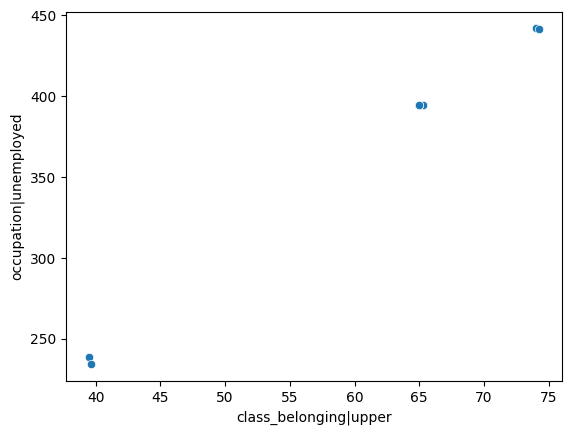

In [32]:
sns.scatterplot(
    data=sub_pivoted_df, x="class_belonging|upper", y="occupation|unemployed"
)

In [37]:
tt = df.groupby(["question_id", "demographic_type"]).size().reset_index()

In [45]:
tt[
    tt["demographic_type"].isin(["class_belonging", "income_difficulty"])
].question_id.nunique()

80

In [46]:
tt.question_id.nunique()

115